# EDUSign – Real-Time Sign Language Learning System

This notebook covers:
- MediaPipe landmark extraction
- Dataset creation (.npz)
- CNN training (TensorFlow/Keras)
- Evaluation (accuracy + confusion matrix)
- Saving the trained model (.h5)


In [1]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt

import cv2
import mediapipe as mp
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

print("OpenCV:", cv2.__version__)
print("MediaPipe:", mp.__version__)
print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)


OpenCV: 4.13.0
MediaPipe: 0.10.9
TensorFlow: 2.12.0
NumPy: 1.23.5


In [2]:
PROJECT_ROOT = r"D:\EDUSign"

DATA_RAW = os.path.join(PROJECT_ROOT, "data", "raw")
DATA_PROCESSED = os.path.join(PROJECT_ROOT, "data", "processed")
MODELS_DIR = os.path.join(PROJECT_ROOT, "models")
RESULTS_DIR = os.path.join(PROJECT_ROOT, "results")

for p in [DATA_RAW, DATA_PROCESSED, MODELS_DIR, RESULTS_DIR]:
    os.makedirs(p, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_PROCESSED:", DATA_PROCESSED)


PROJECT_ROOT: D:\EDUSign
DATA_PROCESSED: D:\EDUSign\data\processed


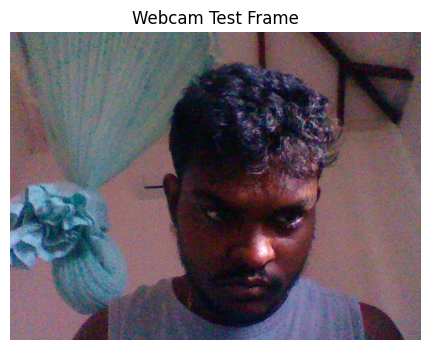

In [6]:
cap = cv2.VideoCapture(0)
if not cap.isOpened():
    raise RuntimeError("Camera not accessible. Try closing other apps using the camera (Zoom/Teams/etc).")

ret, frame = cap.read()
cap.release()

if not ret:
    raise RuntimeError("Failed to grab a frame from the camera.")

# Show one captured frame
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(6,4))
plt.imshow(frame_rgb)
plt.axis("off")
plt.title("Webcam Test Frame")
plt.show()


In [3]:
mp_hands = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils

hands = mp_hands.Hands(
    static_image_mode=False,
    max_num_hands=1,
    model_complexity=1,
    min_detection_confidence=0.6,
    min_tracking_confidence=0.6
)

print("MediaPipe Hands initialized")


MediaPipe Hands initialized


In [8]:
cap = cv2.VideoCapture(0)
start = time.time()

while time.time() - start < 10:  # run for 10 seconds
    ret, frame = cap.read()
    if not ret:
        break

    frame = cv2.flip(frame, 1)  # mirror view
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    results = hands.process(rgb)

    if results.multi_hand_landmarks:
        for hand_landmarks in results.multi_hand_landmarks:
            mp_drawing.draw_landmarks(frame, hand_landmarks, mp_hands.HAND_CONNECTIONS)

    cv2.imshow("MediaPipe Hands Test (10 sec)", frame)

    # press q to quit early
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()
print("Done")


Done


In [4]:
#dataset 
RAW_DATASET_DIR = r"D:\EDUSign\data\raw"

print("RAW_DATASET_DIR =", RAW_DATASET_DIR)
print("Folders inside raw:", os.listdir(RAW_DATASET_DIR)[:20])


RAW_DATASET_DIR = D:\EDUSign\data\raw
Folders inside raw: ['asl_alphabet_train', 'asl_alphabet_train.zip', 'custom_train', 'custom_train.zip']


In [5]:
#7 extra folders

CLASSES = sorted([d for d in os.listdir(RAW_DATASET_DIR) if os.path.isdir(os.path.join(RAW_DATASET_DIR, d))])

print("Detected classes:", CLASSES)
print("Number of classes:", len(CLASSES))


Detected classes: ['asl_alphabet_train', 'custom_train']
Number of classes: 2


In [7]:
RAW_DATASET_DIRS = [
    r"D:\EDUSign\data\raw\asl_alphabet_train",
    r"D:\EDUSign\data\raw\custom_train"
]

for d in RAW_DATASET_DIRS:
    print(d, "->", len(os.listdir(d)), "folders")


D:\EDUSign\data\raw\asl_alphabet_train -> 28 folders
D:\EDUSign\data\raw\custom_train -> 28 folders


In [8]:
def get_all_classes(dataset_dirs):
    classes = set()
    for base in dataset_dirs:
        for d in os.listdir(base):
            full = os.path.join(base, d)
            if os.path.isdir(full):
                classes.add(d)
    return sorted(list(classes))

CLASSES = get_all_classes(RAW_DATASET_DIRS)

print("Detected classes:")
print(CLASSES)
print("Number of classes:", len(CLASSES))


Detected classes:
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'nothing', 'space']
Number of classes: 28


In [14]:
mp_hands = mp.solutions.hands

hands_img = mp_hands.Hands(
    static_image_mode=True,     
    max_num_hands=1,
    model_complexity=1,
    min_detection_confidence=0.6
)

print("MediaPipe (image mode) ready.")


MediaPipe (image mode) ready.


In [10]:
def extract_landmarks_from_bgr_image(img_bgr):
    """
    Extracts 21 hand landmarks from a BGR image using MediaPipe.
    Returns a (63,) numpy array (x,y,z for each landmark),
    or None if no hand is detected.
    """
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    results = hands_img.process(img_rgb)

    if not results.multi_hand_landmarks:
        return None

    hand = results.multi_hand_landmarks[0]
    vec = []
    for lm in hand.landmark:
        vec.extend([lm.x, lm.y, lm.z])

    return np.array(vec, dtype=np.float32)


In [15]:
from pathlib import Path
import os
import cv2
import numpy as np

def build_landmark_dataset_from_multiple_dirs(dataset_dirs, classes, max_images_per_class=None):
    """
    Build a combined landmark dataset from multiple image datasets.

    Assumes each dataset dir contains subfolders named by class label, e.g.:
      base_dir/
        A/ img1.jpg ...
        B/ ...
        space/ ...
        delete/ ...

    Returns:
      X: (N, 63) float32  -> 21 landmarks * (x,y,z)
      y: (N,)  object/str labels
    """
    X, y = [], []
    skipped_no_hand = 0
    skipped_read_fail = 0
    total_scanned = 0
    total_found_images = 0

    for label in classes:
        for base in dataset_dirs:
            class_dir = Path(base) / label
            if not class_dir.exists():
                continue

            # Collect images by extension
            image_paths = []
            for ext in ("*.jpg", "*.jpeg", "*.png"):
                image_paths.extend(class_dir.glob(ext))

            image_paths = sorted(image_paths)
            total_found_images += len(image_paths)

            if max_images_per_class is not None:
                image_paths = image_paths[:max_images_per_class]

            dataset_name = os.path.basename(base)
            print(f"{label} | {dataset_name} | images: {len(image_paths)}")

            for p in image_paths:
                total_scanned += 1
                img = cv2.imread(str(p))
                if img is None:
                    skipped_read_fail += 1
                    continue

                vec = extract_landmarks_from_bgr_image(img)  # must be defined from Step 13
                if vec is None:
                    skipped_no_hand += 1
                    continue

                X.append(vec)
                y.append(label)

    X = np.array(X, dtype=np.float32)
    y = np.array(y)

    print("\n===== SUMMARY =====")
    print("Dataset dirs:", dataset_dirs)
    print("Classes:", len(classes))
    print("Total images found (all classes, before limits):", total_found_images)
    print("Total images scanned (after limits):", total_scanned)
    print("Total samples kept:", len(y))
    print("Skipped (no hand):", skipped_no_hand)
    print("Skipped (read fail):", skipped_read_fail)
    print("X shape:", X.shape, "(expected N x 63)")
    print("y shape:", y.shape)

    return X, y


X, y = build_landmark_dataset_from_multiple_dirs(
    dataset_dirs=RAW_DATASET_DIRS,
    classes=CLASSES,
    max_images_per_class=300
)


A | asl_alphabet_train | images: 300
A | custom_train | images: 300
B | asl_alphabet_train | images: 300
B | custom_train | images: 300
C | asl_alphabet_train | images: 300
C | custom_train | images: 300
D | asl_alphabet_train | images: 300
D | custom_train | images: 300
E | asl_alphabet_train | images: 300
E | custom_train | images: 300
F | asl_alphabet_train | images: 300
F | custom_train | images: 300
G | asl_alphabet_train | images: 300
G | custom_train | images: 300
H | asl_alphabet_train | images: 300
H | custom_train | images: 300
I | asl_alphabet_train | images: 300
I | custom_train | images: 300
J | asl_alphabet_train | images: 300
J | custom_train | images: 300
K | asl_alphabet_train | images: 300
K | custom_train | images: 300
L | asl_alphabet_train | images: 300
L | custom_train | images: 300
M | asl_alphabet_train | images: 300
M | custom_train | images: 300
N | asl_alphabet_train | images: 300
N | custom_train | images: 300
O | asl_alphabet_train | images: 300
O | custom_

In [16]:
dataset_path = os.path.join(DATA_PROCESSED, "landmarks_full_dataset.npz")
np.savez(dataset_path, X=X, y=y, classes=np.array(CLASSES))
print("Saved dataset to:", dataset_path)


Saved dataset to: D:\EDUSign\data\processed\landmarks_full_dataset.npz


In [25]:
unique, counts = np.unique(y, return_counts=True)
for u, c in sorted(zip(unique, counts), key=lambda x: x[0]):
    print(f"{u:>12}: {c}")


           A: 569
           B: 507
           C: 570
           D: 595
           E: 579
           F: 578
           G: 573
           H: 576
           I: 526
           J: 532
           K: 591
           L: 512
           M: 225
           N: 214
           O: 585
           P: 595
           Q: 568
           R: 595
           S: 600
           T: 349
           U: 402
           V: 524
           W: 490
           X: 472
           Y: 322
           Z: 408
       space: 549


In [17]:
label_to_index = {label: i for i, label in enumerate(CLASSES)}
y_idx = np.array([label_to_index[label] for label in y], dtype=np.int32)

print("Example labels:", y[:10])
print("Example encoded:", y_idx[:10])
print("Num classes:", len(CLASSES))


Example labels: ['A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A']
Example encoded: [0 0 0 0 0 0 0 0 0 0]
Num classes: 28


In [18]:
# labels that actually appear in y_idx
present_label_ids = np.unique(np.concatenate([y_test, y_pred]))
present_label_ids = np.sort(present_label_ids)

present_labels = [CLASSES[i] for i in present_label_ids]

print("Classes in plot:", len(present_labels))
print("IDs:", present_label_ids)
print("Labels:", present_labels)
print("CM size should match:", cm.shape)


NameError: name 'y_test' is not defined

In [32]:
all_ids = set(range(len(CLASSES)))
used_ids = set(np.unique(y_idx))

missing_ids = sorted(list(all_ids - used_ids))
print("Missing class count:", len(missing_ids))
print("Missing classes:", [CLASSES[i] for i in missing_ids])


Missing class count: 1
Missing classes: ['nothing']


In [33]:
missing_set = set(missing_ids)
keep_ids = [i for i in range(len(CLASSES)) if i not in missing_set]
keep_classes = [CLASSES[i] for i in keep_ids]

print("Keeping classes:", len(keep_classes))
print("Removed classes:", [CLASSES[i] for i in missing_ids])


Keeping classes: 27
Removed classes: ['nothing']


In [34]:
keep_mask = np.isin(y_idx, keep_ids)
X2 = X[keep_mask]
y2_old = y_idx[keep_mask]

# remap labels to 0..(K-1)
old_to_new = {old: new for new, old in enumerate(keep_ids)}
y2 = np.array([old_to_new[v] for v in y2_old], dtype=np.int32)

CLASSES2 = keep_classes

print("Filtered X:", X2.shape)
print("Filtered y:", y2.shape)
print("New class count:", len(CLASSES2))


Filtered X: (13606, 63)
Filtered y: (13606,)
New class count: 27


Epoch 1/20
137/137 [==============================] - 2s 11ms/step - loss: 2.6023 - accuracy: 0.2389 - val_loss: 1.3613 - val_accuracy: 0.6045
Epoch 2/20
137/137 [==============================] - 1s 10ms/step - loss: 1.0550 - accuracy: 0.6522 - val_loss: 0.4941 - val_accuracy: 0.8548
Epoch 3/20
137/137 [==============================] - 2s 11ms/step - loss: 0.5419 - accuracy: 0.8219 - val_loss: 0.2688 - val_accuracy: 0.9412
Epoch 4/20
137/137 [==============================] - 2s 11ms/step - loss: 0.3439 - accuracy: 0.8950 - val_loss: 0.1986 - val_accuracy: 0.9467
Epoch 5/20
137/137 [==============================] - 2s 14ms/step - loss: 0.2530 - accuracy: 0.9236 - val_loss: 0.1327 - val_accuracy: 0.9678
Epoch 6/20
137/137 [==============================] - 2s 12ms/step - loss: 0.2072 - accuracy: 0.9387 - val_loss: 0.1146 - val_accuracy: 0.9688
Epoch 7/20
137/137 [==============================] - 2s 11ms/step - loss: 0.1847 - accuracy: 0.9469 - val_loss: 0.0776 - val_accuracy: 0.9853

<Figure size 1000x1000 with 0 Axes>

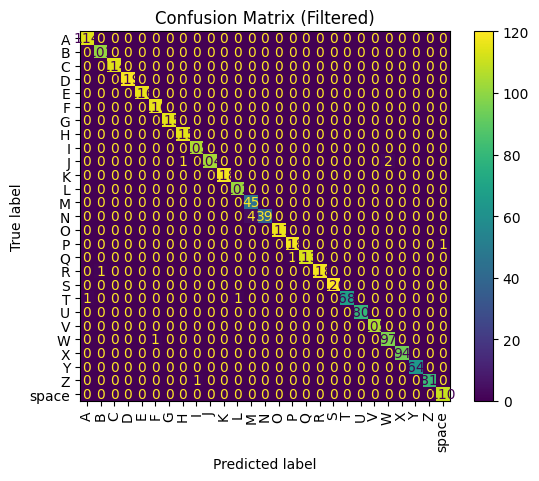

              precision    recall  f1-score   support

           A       0.99      1.00      1.00       114
           B       0.99      1.00      1.00       101
           C       1.00      1.00      1.00       114
           D       1.00      1.00      1.00       119
           E       1.00      1.00      1.00       116
           F       0.99      1.00      1.00       116
           G       1.00      1.00      1.00       115
           H       0.99      1.00      1.00       115
           I       0.99      1.00      1.00       105
           J       1.00      0.97      0.99       107
           K       1.00      1.00      1.00       118
           L       0.99      1.00      1.00       102
           M       0.92      1.00      0.96        45
           N       1.00      0.91      0.95        43
           O       1.00      1.00      1.00       117
           P       0.99      0.99      0.99       119
           Q       1.00      0.99      1.00       114
           R       1.00    

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

num_classes = len(CLASSES2)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(63,)),
    tf.keras.layers.Reshape((63, 1)),
    tf.keras.layers.Conv1D(64, 5, activation="relu"),
    tf.keras.layers.MaxPooling1D(2),
    tf.keras.layers.Conv1D(128, 5, activation="relu"),
    tf.keras.layers.MaxPooling1D(2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(num_classes, activation="softmax"),
])

model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    verbose=1
)

y_pred = np.argmax(model.predict(X_test), axis=1)

cm = confusion_matrix(y_test, y_pred, labels=list(range(len(CLASSES2))))
disp = ConfusionMatrixDisplay(cm, display_labels=CLASSES2)
plt.figure(figsize=(10,10))
disp.plot(xticks_rotation=90, values_format="d")
plt.title("Confusion Matrix (Filtered)")
plt.show()

print(classification_report(y_test, y_pred, target_names=CLASSES2))


In [36]:
model_path = os.path.join(MODELS_DIR, "sign_cnn.h5")
model.save(model_path)

labels_path = os.path.join(MODELS_DIR, "labels.npy")
np.save(labels_path, np.array(CLASSES2))

print("Saved model:", model_path)
print("Saved labels:", labels_path)


Saved model: D:\EDUSign\models\sign_cnn.h5
Saved labels: D:\EDUSign\models\labels.npy


In [37]:
y_pred = np.argmax(model.predict(X_test), axis=1)
print("y_test unique:", len(np.unique(y_test)))
print("y_pred unique:", len(np.unique(y_pred)))


86/86 [==============================] - 0s 2ms/step
y_test unique: 27
y_pred unique: 27


<Figure size 1000x1000 with 0 Axes>

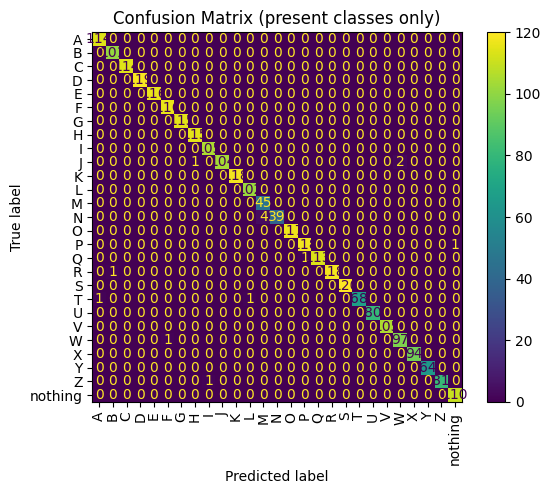

In [38]:
# Use only classes that appear in test or predictions
present_label_ids = np.unique(np.concatenate([y_test, y_pred]))
present_label_ids = np.sort(present_label_ids)

present_labels = [CLASSES[i] for i in present_label_ids]

cm_present = confusion_matrix(y_test, y_pred, labels=present_label_ids)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_present, display_labels=present_labels)
plt.figure(figsize=(10, 10))
disp.plot(xticks_rotation=90, values_format="d")
plt.title("Confusion Matrix (present classes only)")
plt.show()


In [39]:
import os
print(os.path.exists(r"D:\EDUSign\models\sign_cnn.h5"), "model exists")
print(os.path.exists(r"D:\EDUSign\models\labels.npy"), "labels exists")


True model exists
True labels exists


In [40]:
import numpy as np
import os

dataset_path = os.path.join(r"D:\EDUSign\data\processed", "landmarks_full_dataset.npz")
data = np.load(dataset_path, allow_pickle=True)

X = data["X"]
y = data["y"]
CLASSES = data["classes"].tolist()

print("Loaded:", dataset_path)
print("X:", X.shape, "y:", y.shape, "classes:", len(CLASSES))


Loaded: D:\EDUSign\data\processed\landmarks_full_dataset.npz
X: (13606, 63) y: (13606,) classes: 28


In [19]:
model_path = os.path.join(MODELS_DIR, "sign_cnn.h5")
model = tf.keras.models.load_model(model_path)
print("Loaded model:", model_path)


Loaded model: D:\EDUSign\models\sign_cnn.h5


In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_idx,
    test_size=0.2,
    random_state=42,
    stratify=y_idx
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)


Train: (10884, 63)
Test : (2722, 63)


In [13]:
import tensorflow as tf

model_path = os.path.join(MODELS_DIR, "sign_cnn.h5")
model = tf.keras.models.load_model(model_path)

print("Model loaded")


Model loaded


86/86 [==============================] - 0s 3ms/step


<Figure size 1000x1000 with 0 Axes>

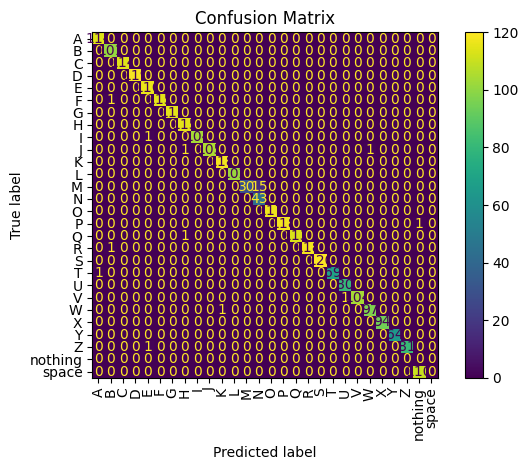

Saved: D:\EDUSign\results\confusion_matrix.png
              precision    recall  f1-score   support

           A       0.99      1.00      1.00       114
           B       0.98      1.00      0.99       101
           C       1.00      1.00      1.00       114
           D       1.00      1.00      1.00       119
           E       0.98      1.00      0.99       116
           F       1.00      0.99      1.00       116
           G       1.00      1.00      1.00       115
           H       0.98      1.00      0.99       115
           I       1.00      0.99      1.00       105
           J       1.00      0.98      0.99       107
           K       0.99      1.00      1.00       118
           L       1.00      1.00      1.00       102
           M       1.00      0.67      0.80        45
           N       0.74      1.00      0.85        43
           O       1.00      1.00      1.00       117
           P       1.00      0.99      1.00       119
           Q       1.00      0.99 

C:\Users\ASUS\anaconda3\envs\sign_env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ASUS\anaconda3\envs\sign_env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ASUS\anaconda3\envs\sign_env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\

In [40]:
y_pred = np.argmax(model.predict(X_test), axis=1)

present_ids = np.unique(np.concatenate([y_test, y_pred]))
present_labels = [CLASSES[i] for i in present_ids]

cm = confusion_matrix(y_test, y_pred, labels=present_ids)

disp = ConfusionMatrixDisplay(cm, display_labels=present_labels)
plt.figure(figsize=(10, 10))
disp.plot(xticks_rotation=90, values_format="d")
plt.title("Confusion Matrix")
plt.tight_layout()

cm_path = os.path.join(RESULTS_DIR, "confusion_matrix.png")
plt.savefig(cm_path, dpi=200)
plt.show()

print("Saved:", cm_path)
print(classification_report(y_test, y_pred, target_names=present_labels))
